In [6]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# ---------------- Configuration ----------------
BATCH_SIZE = 64
NUM_EPOCHS = 10
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ---------------- Data Transforms ----------------
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

# ---------------- Dataset Loading ----------------
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_size = int(0.8 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valloader = DataLoader(valset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Using device: cuda


100%|██████████| 170M/170M [00:01<00:00, 90.5MB/s] 


In [7]:

# ---------------- Helper Functions ----------------
def adapt_model(model: nn.Module) -> nn.Module:
    """Adapt pretrained model for CIFAR-10 classification."""
    if hasattr(model, 'fc'):
        model.fc = nn.Linear(model.fc.in_features, 10)
    elif hasattr(model, 'classifier'):
        if isinstance(model, models.SqueezeNet):
            model.classifier[1] = nn.Conv2d(512, 10, kernel_size=(1, 1))
        elif isinstance(model.classifier, nn.Sequential):
            for i in reversed(range(len(model.classifier))):
                if isinstance(model.classifier[i], nn.Linear):
                    model.classifier[i] = nn.Linear(model.classifier[i].in_features, 10)
                    break
        elif isinstance(model.classifier, nn.Linear):
            model.classifier = nn.Linear(model.classifier.in_features, 10)
    return model


def plot_history(histories):
    """Plot training and validation history for multiple models."""
    for name, history in histories.items():
        train_losses = history["train_loss"]
        val_losses = history["val_loss"]
        val_accs = history["val_acc"]
        test_accs = history["test_acc"]
        plt.figure(figsize=(12, 5))
        
        # Loss plot
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Validation Loss')
        plt.title(f'{name} Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()

        # Accuracy plot
        plt.subplot(1, 2, 2)
        plt.plot(val_accs, label='Validation Accuracy')
        # for test_acc in test_accs:
        #     plt.hlines(test_acc, 0, len(val_accs)-1, colors='r', linestyles='--',
        #                label=f'Test Accuracy {test_acc:.2f}%')
        plt.hlines(test_accs, 0, len(val_accs)-1, colors='r', linestyles='--',label=f'Test Accuracy {test_accs:.2f}%')
        plt.title(f'{name} Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.legend()
        plt.show()
#the accuacy of classes per model
def accuracy_heatmap(histories):
    """Plot heatmap of per-class accuracy for all models."""
    data = []
    for model_name, history in histories.items():
        class_accs = history["class_acc"]  # dict: class -> acc
        data.append(class_accs)
    # Convert to DataFrame
    df = pd.DataFrame(data, index=histories.keys())
    plt.figure(figsize=(12, 6))
    sns.heatmap(df, annot=True, fmt=".1f", cmap="coolwarm")
    plt.title("Per-Class Accuracy Heatmap (Model Weakness Map)")
    plt.xlabel("Classes")
    plt.ylabel("Models")
    plt.show()
#confusion matrix fror the best single model
def confusion_matrix_comparison(histories_best_model):
    y_true = histories_best_model["y_true"]  # True labels
    y_pred = histories_best_model["y_pred"]  # Predicted labels
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=testset.classes, yticklabels=testset.classes)
    plt.title("Confusion Matrix for Best Single Model", fontsize=15)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()


In [8]:

# ---------------- Task 1: Model Comparison ----------------
def run_task1():
    models_dict = {
        "ResNet18": models.resnet18,
        "AlexNet": models.alexnet,
        "VGG16": models.vgg16,
        "SqueezeNet": models.squeezenet1_0,
        "DenseNet121": models.densenet121,
        "ResNeXt50_32x4d": models.resnext50_32x4d,
        "GoogLeNet": models.googlenet
    }

    results, histories = {}, {}

    for name, model_fn in models_dict.items():
        print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
        model = adapt_model(model_fn(weights='IMAGENET1K_V1')).to(DEVICE)

        # Freeze all layers except classifier
        for param in model.parameters():
            param.requires_grad = False
        if hasattr(model, 'fc'):
            for param in model.fc.parameters():
                param.requires_grad = True
        elif hasattr(model, 'classifier'):
            for param in model.classifier.parameters():
                param.requires_grad = True

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

        train_losses, val_losses, val_accs = [], [], []
        best_val_acc, patience, counter = 0, 3, 0

        for epoch in range(NUM_EPOCHS):
            # ---- Training ----
            model.train()
            total_loss = 0.0
            for inputs, labels in trainloader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            train_losses.append(total_loss / len(trainloader))

            # ---- Validation ----
            model.eval()
            correct, total, val_loss = 0, 0, 0.0
            with torch.no_grad():
                for inputs, labels in valloader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    _, predicted = outputs.max(1)
                    correct += predicted.eq(labels).sum().item()
                    total += labels.size(0)
            val_acc = 100 * correct / total
            val_losses.append(val_loss / len(valloader))
            val_accs.append(val_acc)

            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_losses[-1]:.3f} | "
                  f"Val Loss: {val_losses[-1]:.3f} | Val Acc: {val_acc:.2f}%")

            # ---- Early stopping ----
            if val_acc > best_val_acc:
                best_val_acc, counter = val_acc, 0
                torch.save(model.state_dict(), f"best_{name}.pth")
            else:
                counter += 1
                if counter >= patience:
                    print("Early stopping.")
                    break

        # ---- Test Evaluation ----
        model.load_state_dict(torch.load(f"best_{name}.pth"))
        model.eval()
        correct, total = 0, 0
        class_names = testset.classes
        class_accs = {name: 0 for name in class_names}
        total_per_class = {name: 0 for name in class_names}
        y_true, y_pred = [], []
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)#result predicted by the model we compare with the real labels
                _, predicted = outputs.max(1)
                correct += predicted.eq(labels).sum().item()
                total += labels.size(0)
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
                for i in range(labels.size(0)):
                    class_name = class_names[labels[i].item()]
                    total_per_class[class_name] += 1
                    if labels[i].item() == predicted[i].item():
                        class_accs[class_name] += 1
                        
                
        test_acc = 100 * correct / total
        class_accs = {name: 100 * class_accs[name] / total_per_class[name] for name in class_names}
        # Store class name and accuracy for heatmap
        results[name] = test_acc
        histories[name] = {
    "train_loss": train_losses,
    "val_loss": val_losses,
    "val_acc": val_accs,
    "class_acc": class_accs,
    "test_acc": test_acc,
    "y_true": y_true,
    "y_pred": y_pred
}
        # histories[name] = (train_losses, val_losses, val_accs, class_accs, y_true, y_pred, [test_acc])
        print(f"Test Accuracy of {name}: {test_acc:.2f}%")

    sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
    print(f"\n{'='*60}\nFINAL MODEL COMPARISON\n{'='*60}")
    for model_name, acc in sorted_results:
        print(f"{model_name:<15}{acc:.2f}%")
    # separate names and accuracies
    model_names = [model for model, acc in sorted_results]
    accuracies = [acc for model, acc in sorted_results]

    # create bar chart
    plt.figure()
    plt.bar(model_names, accuracies)

    # labels and title
    plt.xlabel("Models")
    plt.ylabel("Accuracy (%)")
    plt.title("Model Accuracies Comparison")

    # rotate names if needed
    plt.xticks(rotation=45)
    print(f"\nBEST MODEL: {sorted_results[0][0]} ({sorted_results[0][1]:.2f}%)")

    return sorted_results, models_dict, histories


In [9]:

# ---------------- Task 2: Ensemble 3 MOdels ----------------
class Top3BootstrapEnsemble(nn.Module):
    def __init__(self, top_3_models, device=DEVICE):
        super().__init__()
        self.device = device
        self.estimators = nn.ModuleList()
        for name, cls, acc in top_3_models:
            print(f"Loading {name} ({acc:.2f}%)")
            model = adapt_model(cls(weights='IMAGENET1K_V1')).to(device)
            model.load_state_dict(torch.load(f"best_{name}.pth"))
            self.estimators.append(model)

    def create_bootstrap_samples(self, dataset, n_samples=3):
        size = len(dataset)
        loaders = []
        for i in range(n_samples):
            indices = torch.randint(0, size, (size,), dtype=torch.int64)
            subset = Subset(dataset, indices)
            loaders.append(DataLoader(subset, batch_size=BATCH_SIZE,
                                      shuffle=True, num_workers=NUM_WORKERS))
        return loaders

    def fine_tune(self, loaders, names, epochs=5):
        criterion = nn.CrossEntropyLoss()
        for idx, (model, loader, name) in enumerate(zip(self.estimators, loaders, names)):
            print(f"\nFine-tuning {name} (Model {idx+1})")
            for p in model.parameters():
                p.requires_grad = False
            if hasattr(model, 'fc'):
                for p in model.fc.parameters():
                    p.requires_grad = True
            elif hasattr(model, 'classifier'):
                for p in model.classifier.parameters():
                    p.requires_grad = True
            optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
            model.train()
            for epoch in range(epochs):
                loss_sum, correct, total = 0, 0, 0
                for data, target in loader:
                    data, target = data.to(self.device), target.to(self.device)
                    optimizer.zero_grad()
                    output = model(data)
                    loss = criterion(output, target)
                    loss.backward()
                    optimizer.step()
                    loss_sum += loss.item()
                    _, pred = output.max(1)
                    correct += pred.eq(target).sum().item()
                    total += target.size(0)
                print(f"Epoch {epoch+1}/{epochs} | Loss: {loss_sum/len(loader):.4f} | "
                      f"Acc: {100*correct/total:.2f}%")

    def predict(self, x):
        self.eval()
        with torch.no_grad():
            probs = [F.softmax(model(x), dim=1) for model in self.estimators]
            mean_prob = torch.mean(torch.stack(probs), dim=0)
            return mean_prob.argmax(1), mean_prob



Training ResNet18
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s] 


Epoch 1/10 | Train Loss: 1.126 | Val Loss: 0.813 | Val Acc: 74.05%
Epoch 2/10 | Train Loss: 0.777 | Val Loss: 0.725 | Val Acc: 75.87%
Epoch 3/10 | Train Loss: 0.724 | Val Loss: 0.694 | Val Acc: 76.46%
Epoch 4/10 | Train Loss: 0.695 | Val Loss: 0.669 | Val Acc: 76.99%
Epoch 5/10 | Train Loss: 0.675 | Val Loss: 0.656 | Val Acc: 77.69%
Epoch 6/10 | Train Loss: 0.664 | Val Loss: 0.663 | Val Acc: 77.27%
Epoch 7/10 | Train Loss: 0.656 | Val Loss: 0.647 | Val Acc: 77.31%
Epoch 8/10 | Train Loss: 0.644 | Val Loss: 0.636 | Val Acc: 78.31%
Epoch 9/10 | Train Loss: 0.644 | Val Loss: 0.621 | Val Acc: 78.65%
Epoch 10/10 | Train Loss: 0.639 | Val Loss: 0.619 | Val Acc: 78.79%
Test Accuracy of ResNet18: 79.18%

Training AlexNet
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 207MB/s] 


Epoch 1/10 | Train Loss: 0.873 | Val Loss: 0.647 | Val Acc: 77.11%
Epoch 2/10 | Train Loss: 0.693 | Val Loss: 0.581 | Val Acc: 80.08%
Epoch 3/10 | Train Loss: 0.647 | Val Loss: 0.550 | Val Acc: 80.47%
Epoch 4/10 | Train Loss: 0.610 | Val Loss: 0.534 | Val Acc: 81.18%
Epoch 5/10 | Train Loss: 0.590 | Val Loss: 0.519 | Val Acc: 81.39%
Epoch 6/10 | Train Loss: 0.567 | Val Loss: 0.512 | Val Acc: 81.94%
Epoch 7/10 | Train Loss: 0.545 | Val Loss: 0.484 | Val Acc: 83.05%
Epoch 8/10 | Train Loss: 0.535 | Val Loss: 0.487 | Val Acc: 82.93%
Epoch 9/10 | Train Loss: 0.527 | Val Loss: 0.473 | Val Acc: 83.27%
Epoch 10/10 | Train Loss: 0.509 | Val Loss: 0.476 | Val Acc: 83.16%
Test Accuracy of AlexNet: 84.59%

Training VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


...

Epoch 1/10 | Train Loss: 1.125 | Val Loss: 0.786 | Val Acc: 75.79%
Epoch 2/10 | Train Loss: 0.767 | Val Loss: 0.703 | Val Acc: 76.85%
Epoch 3/10 | Train Loss: 0.711 | Val Loss: 0.666 | Val Acc: 77.94%
Epoch 4/10 | Train Loss: 0.675 | Val Loss: 0.645 | Val Acc: 78.38%
Epoch 5/10 | Train Loss: 0.658 | Val Loss: 0.635 | Val Acc: 78.68%
Epoch 6/10 | Train Loss: 0.642 | Val Loss: 0.620 | Val Acc: 78.97%
Epoch 7/10 | Train Loss: 0.637 | Val Loss: 0.618 | Val Acc: 78.88%
Epoch 8/10 | Train Loss: 0.623 | Val Loss: 0.619 | Val Acc: 78.77%
Epoch 9/10 | Train Loss: 0.614 | Val Loss: 0.604 | Val Acc: 79.08%
Epoch 10/10 | Train Loss: 0.618 | Val Loss: 0.601 | Val Acc: 79.21%
Test Accuracy of DenseNet121: 80.33%

Training ResNeXt50_32x4d
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 174MB/s] 


Epoch 1/10 | Train Loss: 1.142 | Val Loss: 0.817 | Val Acc: 75.30%
Epoch 2/10 | Train Loss: 0.768 | Val Loss: 0.710 | Val Acc: 77.15%
Epoch 3/10 | Train Loss: 0.704 | Val Loss: 0.671 | Val Acc: 78.05%
Epoch 4/10 | Train Loss: 0.670 | Val Loss: 0.651 | Val Acc: 78.53%
Epoch 5/10 | Train Loss: 0.651 | Val Loss: 0.618 | Val Acc: 79.46%
Epoch 6/10 | Train Loss: 0.632 | Val Loss: 0.607 | Val Acc: 80.04%
Epoch 7/10 | Train Loss: 0.628 | Val Loss: 0.597 | Val Acc: 80.18%
Epoch 8/10 | Train Loss: 0.618 | Val Loss: 0.596 | Val Acc: 80.24%
Epoch 9/10 | Train Loss: 0.612 | Val Loss: 0.589 | Val Acc: 80.64%
Epoch 10/10 | Train Loss: 0.600 | Val Loss: 0.591 | Val Acc: 80.10%
Test Accuracy of ResNeXt50_32x4d: 80.57%

Training GoogLeNet
Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 185MB/s]


Epoch 1/10 | Train Loss: 1.507 | Val Loss: 1.089 | Val Acc: 70.65%
Epoch 2/10 | Train Loss: 1.020 | Val Loss: 0.904 | Val Acc: 72.77%
Epoch 3/10 | Train Loss: 0.910 | Val Loss: 0.826 | Val Acc: 74.26%
Epoch 4/10 | Train Loss: 0.855 | Val Loss: 0.788 | Val Acc: 74.74%
Epoch 5/10 | Train Loss: 0.828 | Val Loss: 0.768 | Val Acc: 74.96%
Epoch 6/10 | Train Loss: 0.809 | Val Loss: 0.738 | Val Acc: 76.01%
Epoch 7/10 | Train Loss: 0.794 | Val Loss: 0.713 | Val Acc: 77.04%
Epoch 8/10 | Train Loss: 0.782 | Val Loss: 0.713 | Val Acc: 76.60%
Epoch 9/10 | Train Loss: 0.770 | Val Loss: 0.700 | Val Acc: 77.09%
Epoch 10/10 | Train Loss: 0.763 | Val Loss: 0.704 | Val Acc: 76.55%
Test Accuracy of GoogLeNet: 77.12%

FINAL MODEL COMPARISON
VGG16          87.33%
AlexNet        84.59%
SqueezeNet     81.28%
ResNeXt50_32x4d80.57%
DenseNet121    80.33%
ResNet18       79.18%
GoogLeNet      77.12%

BEST MODEL: VGG16 (87.33%)


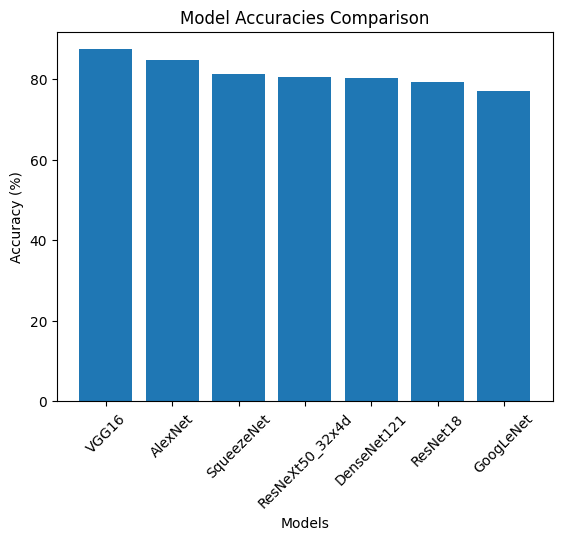

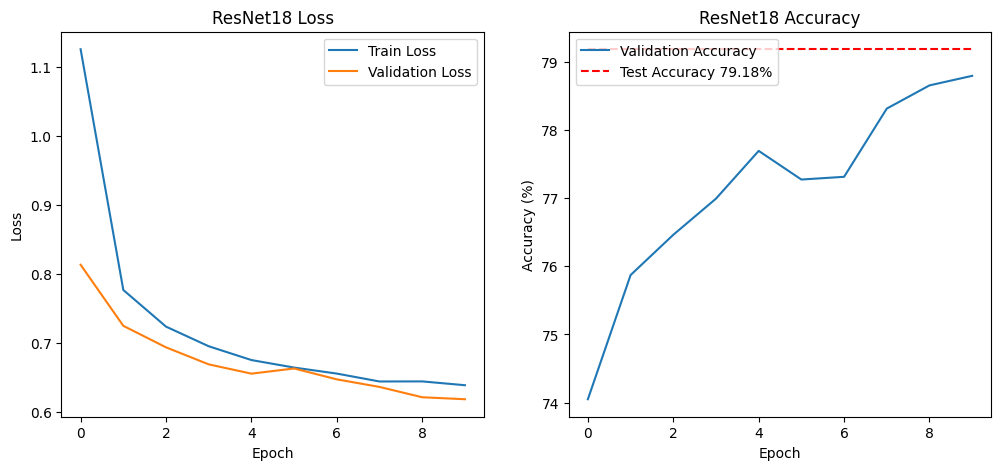

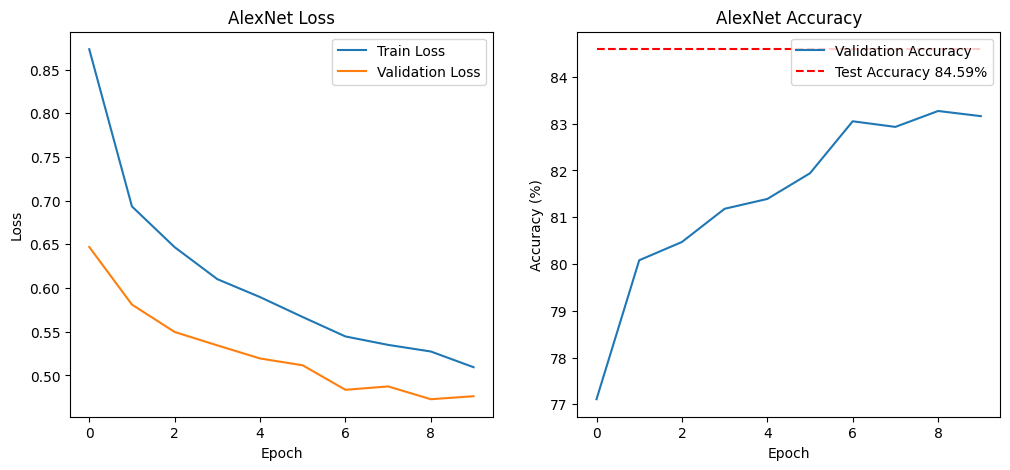

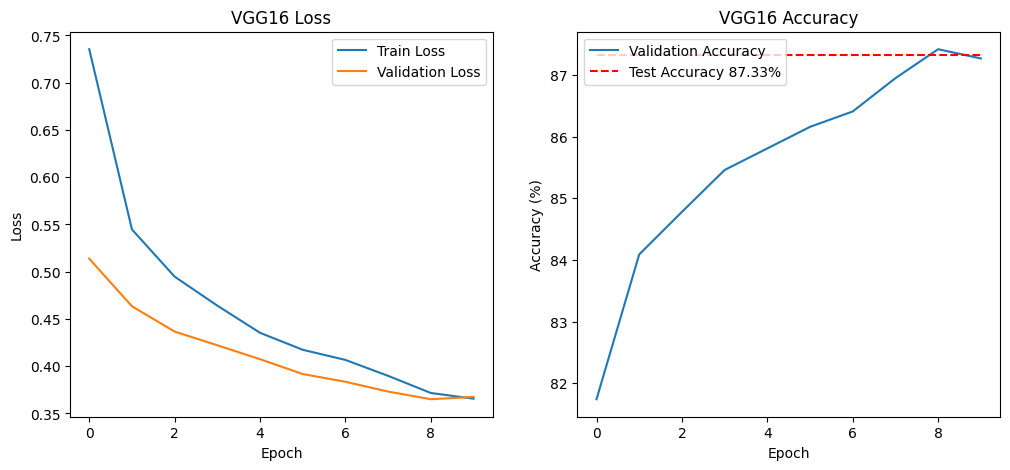

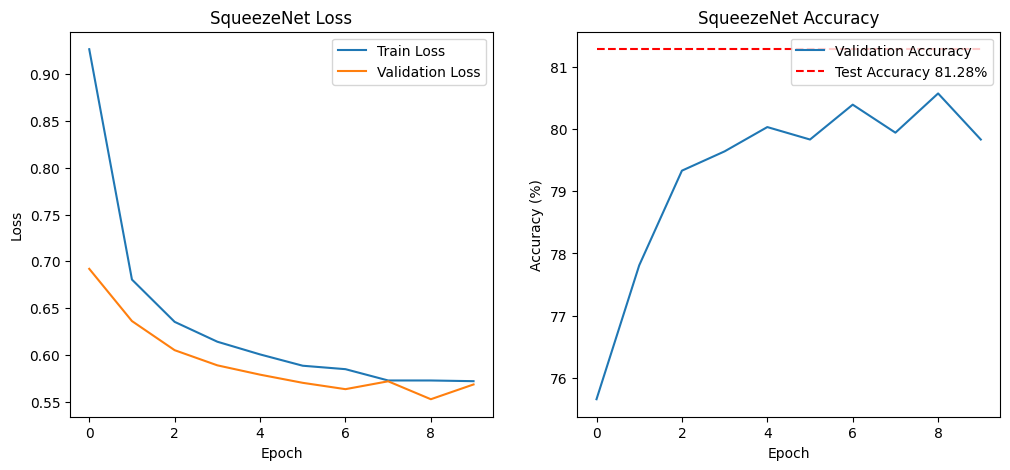

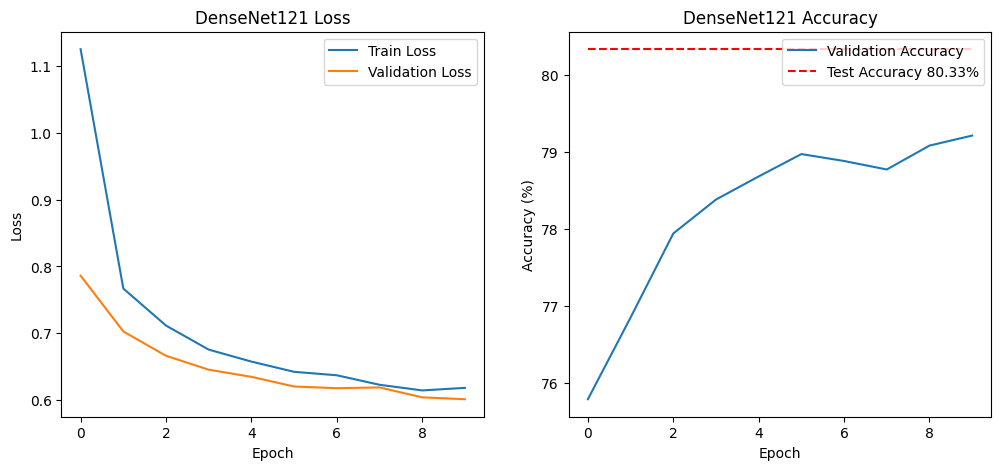

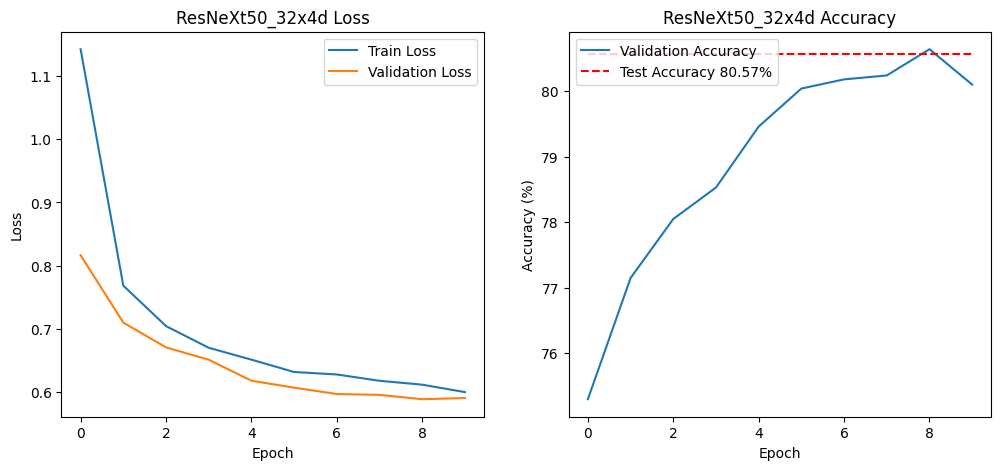

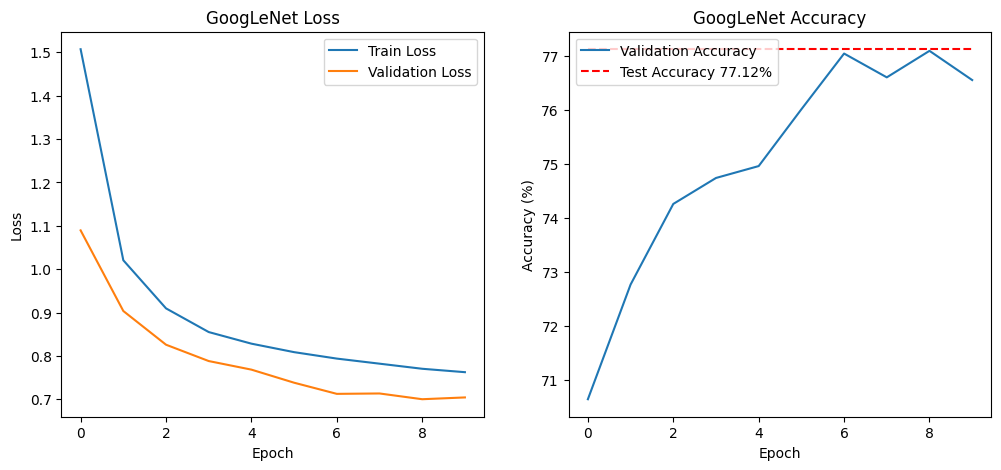

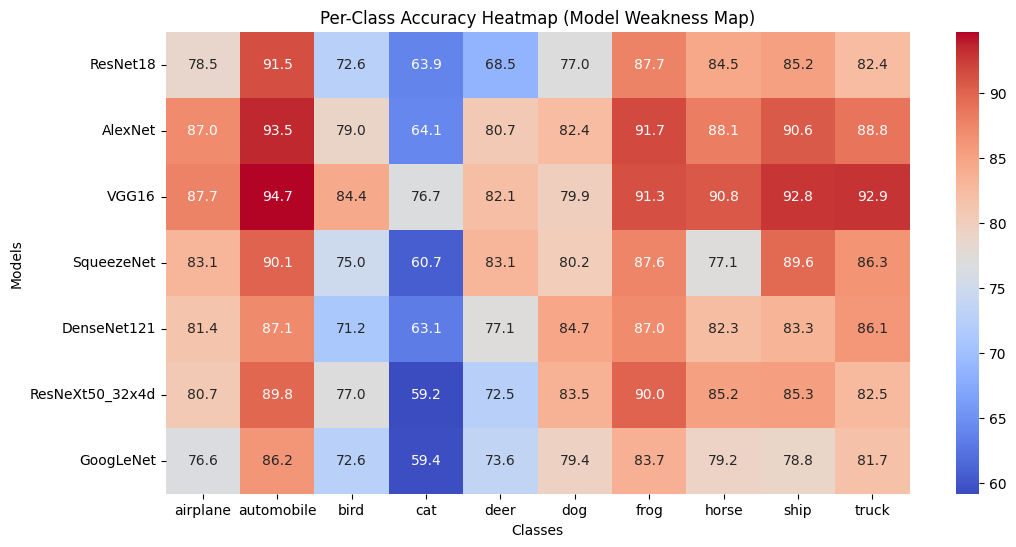


Top 3 Models for Ensemble
1. VGG16: 87.33%
2. AlexNet: 84.59%
3. SqueezeNet: 81.28%
Loading VGG16 (87.33%)
Loading AlexNet (84.59%)
Loading SqueezeNet (81.28%)

Fine-tuning VGG16 (Model 1)
Epoch 1/3 | Loss: 0.4517 | Acc: 84.24%
Epoch 2/3 | Loss: 0.3693 | Acc: 87.10%
Epoch 3/3 | Loss: 0.3146 | Acc: 88.84%

Fine-tuning AlexNet (Model 2)
Epoch 1/3 | Loss: 0.5744 | Acc: 79.71%
Epoch 2/3 | Loss: 0.4995 | Acc: 82.35%
Epoch 3/3 | Loss: 0.4538 | Acc: 84.04%

Fine-tuning SqueezeNet (Model 3)
Epoch 1/3 | Loss: 0.5447 | Acc: 80.89%
Epoch 2/3 | Loss: 0.5392 | Acc: 81.25%
Epoch 3/3 | Loss: 0.5292 | Acc: 81.58%


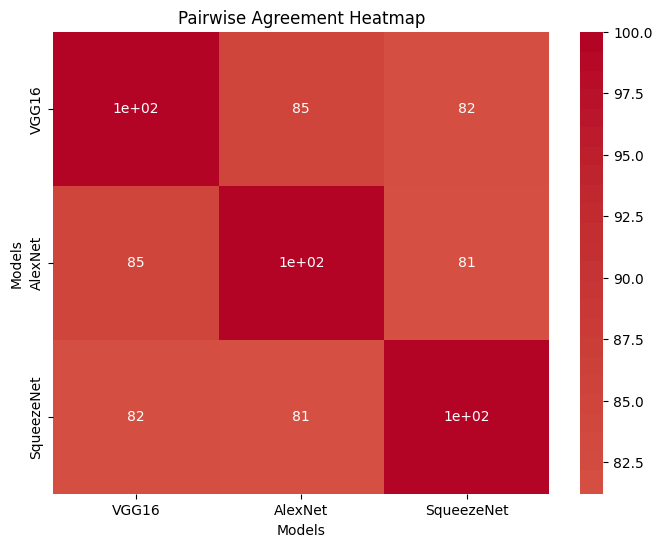

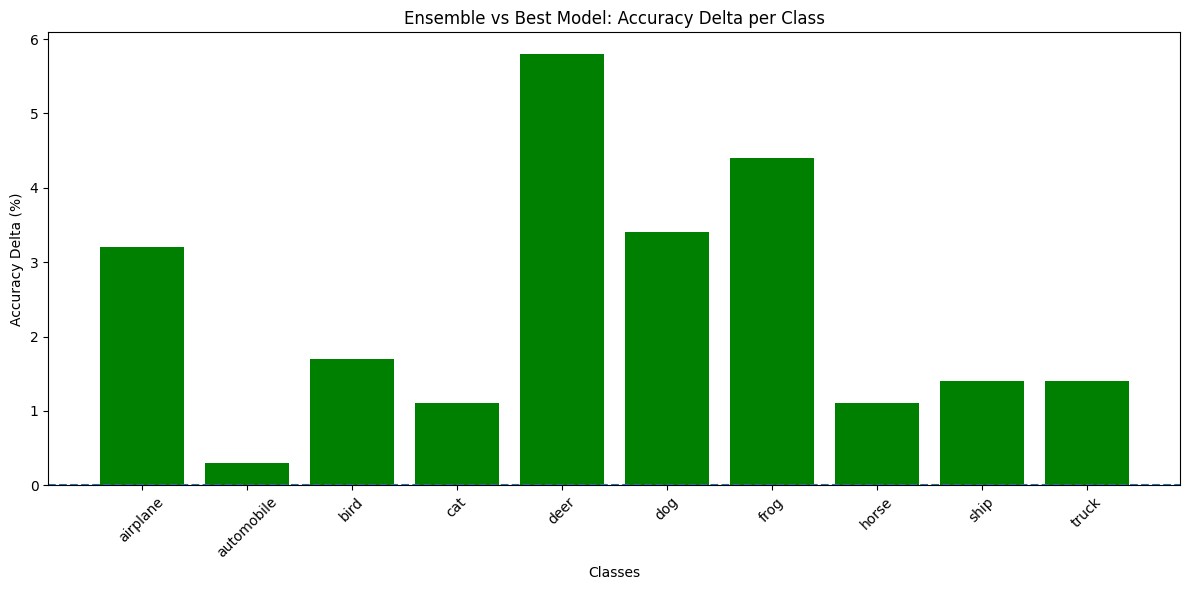


ENSEMBLE RESULTS
VGG16: 87.33%
AlexNet: 84.59%
SqueezeNet: 81.28%

Ensemble Accuracy: 89.71%
Improvement: +2.38%

ENSEMBLE CONFUSION MATRIX


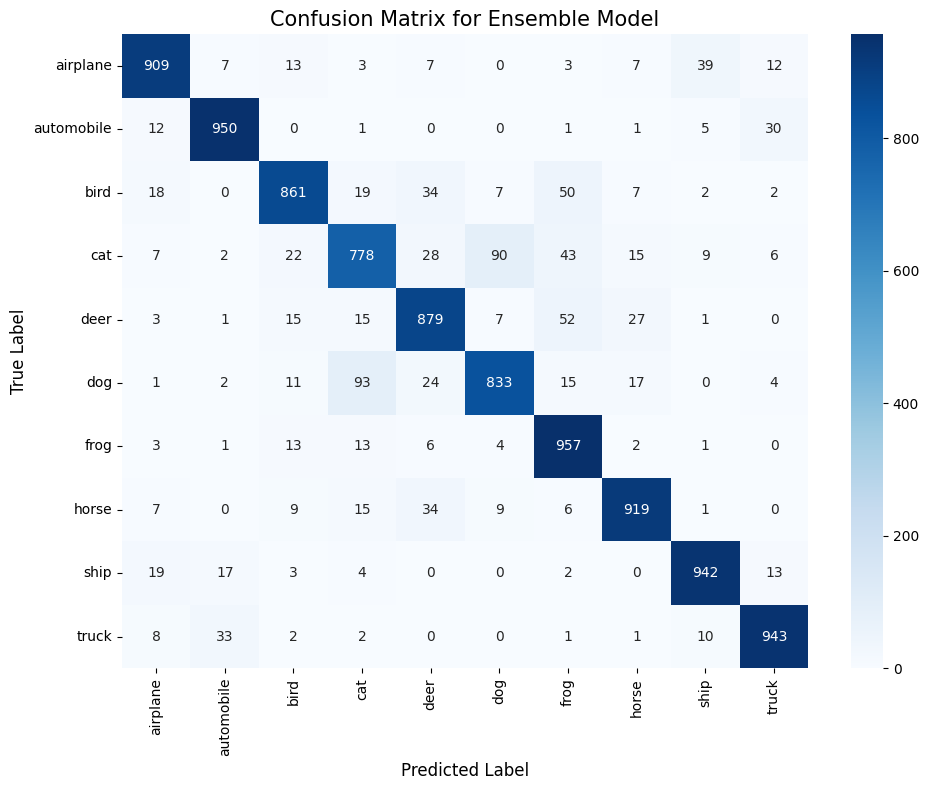


BEST MODEL CONFUSION MATRIX


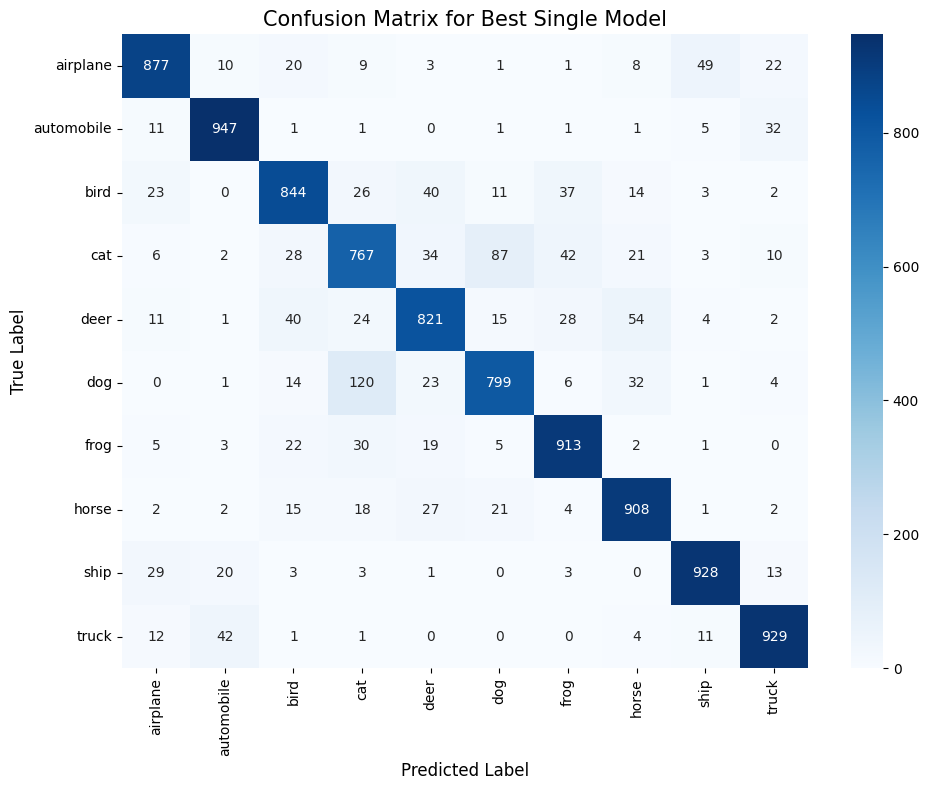

In [10]:

if __name__ == "__main__":
    sorted_results, models_dict, histories = run_task1()
    plot_history(histories)
    accuracy_heatmap(histories)

    #y_predcited bythe top 3 models 
    predictions_top3 = {name: histories[name]["y_pred"] for name, acc in sorted_results[:3]}

    top_3 = [(name, models_dict[name], acc) for name, acc in sorted_results[:3]]
    print(f"\n{'='*60}\nTop 3 Models for Ensemble\n{'='*60}")
    for i, (name, _, acc) in enumerate(top_3, 1):
        print(f"{i}. {name}: {acc:.2f}%")

    ensemble = Top3BootstrapEnsemble(top_3, device=DEVICE)
    bootstrap_loaders = ensemble.create_bootstrap_samples(full_trainset, n_samples=3)
    ensemble.fine_tune(bootstrap_loaders, [m[0] for m in top_3], epochs=3)

    #heatmap of pairwise agreement
    agreement_matrix = [[100 if i==j else (sum(p1==p2 for p1,p2 in zip(predictions_top3[sorted_results[i][0]], predictions_top3[sorted_results[j][0]]))/len(predictions_top3[sorted_results[i][0]]))*100 for j in range(3)] for i in range(3)]    
    plt.figure(figsize=(8, 6))
    sns.heatmap(agreement_matrix, annot=True, cmap="coolwarm", center=0.5, xticklabels=[m[0] for m in top_3], yticklabels=[m[0] for m in top_3])
    plt.title("Pairwise Agreement Heatmap")
    plt.xlabel("Models")
    plt.ylabel("Models")
    plt.show()
    # Evaluate ensemble
    ensemble.eval()
    correct, total = 0, 0
    y_true_ensemble, y_pred_ensemble = [], []
    class_names = testset.classes
    class_accs = {name: 0 for name in class_names}
    total_per_class = {name: 0 for name in class_names}    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            preds, _ = ensemble.predict(images)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            y_true_ensemble.extend(labels.cpu().numpy())
            y_pred_ensemble.extend(preds.cpu().numpy())
            for i in range(labels.size(0)):
                class_name = class_names[labels[i].item()]
                total_per_class[class_name] += 1
                if labels[i].item() == preds[i].item():
                    class_accs[class_name] += 1

    ensemble_acc = 100 * correct / total
    best_single = top_3[0][2]
    # Calculate per-class accuracy for ensemble model
    class_accs = {name: 100 * class_accs[name] / total_per_class[name] for name in class_names}
    #per-class accuracy of best single model
    best_single_class_accs = histories[top_3[0][0]]["class_acc"]
    #delta of per-class accuracy between ensemble and best single model
    delta_class_accs = {name: class_accs[name] - best_single_class_accs[name] for name in class_names}
    #Win/Loss Chart
    classes = list(delta_class_accs.keys())
    deltas = list(delta_class_accs.values())
    # Colors: green = improvement, red = worse
    colors = ["green" if d > 0 else "red" for d in deltas]
    plt.figure(figsize=(12, 6))
    plt.bar(classes, deltas, color=colors)
    plt.axhline(0, linestyle='--')

    plt.title("Ensemble vs Best Model: Accuracy Delta per Class")
    plt.xlabel("Classes")
    plt.ylabel("Accuracy Delta (%)")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}\nENSEMBLE RESULTS\n{'='*60}")
    for name, _, acc in top_3:
        print(f"{name}: {acc:.2f}%")
    print(f"\nEnsemble Accuracy: {ensemble_acc:.2f}%")
    print(f"Improvement: {ensemble_acc - best_single:+.2f}%")
    #confusion matrix for ensemble
    print(f"\n{'='*60}\nENSEMBLE CONFUSION MATRIX\n{'='*60}")
    cm = confusion_matrix(y_true_ensemble, y_pred_ensemble)
    plt.figure(figsize=(10, 8)) 
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=testset.classes, yticklabels=testset.classes)
    plt.title("Confusion Matrix for Ensemble Model", fontsize=15)
    plt.xlabel("Predicted Label", fontsize=12)
    plt.ylabel("True Label", fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*60}\nBEST MODEL CONFUSION MATRIX\n{'='*60}")
    confusion_matrix_comparison(histories[sorted_results[0][0]]) 